<a href="https://colab.research.google.com/github/DeepFluxion/2026_2_IBMEC_PROG_ANALISE_DADOS/blob/main/notebooks/Aula10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
np.set_printoptions(suppress=True)
import pandas as pd
pd.set_option("display.max_columns", None)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

<img src="https://keystoneacademic-res.cloudinary.com/image/upload/c_pad,w_640,h_304/dpr_auto/f_auto/q_auto/v1/element/94/94774_thumb.png" width=300>

# Programação para Análise de Dados

## Aula 10: Visualização de Dados

### Professor: Carlos E. Leal de Castro

#### ⚠️ BAIXEM ⚠️ Materiais da aula: `Aula10.ipynb` e `.csv`

A Análise Exploratória de Dados (AED ou EDA, em inglês) é o processo de investigar um conjunto de dados para descobrir padrões, anomalias (outliers) e testar hipóteses. A visualização de dados é o pilar dessa investigação.

**Por que visualizar?**
- Identificação de Padrões: Nosso cérebro processa informações visuais muito mais rápido do que texto ou tabelas. Gráficos revelam tendências, sazonalidades e relações que seriam difíceis de perceber em dados brutos.

- Detecção de Outliers: Valores atípicos que podem distorcer análises estatísticas ficam evidentes em gráficos como box plots e scatter plots.

- Comunicação de Resultados: Uma visualização bem-feita é uma forma universal e poderosa de comunicar as conclusões da sua análise para diferentes públicos.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np

df = sns.load_dataset("anscombe")

def estatisticas_ascombe():
    # Mostrar estatísticas descritivas (média, variância, correlação)
    print("EXEMPLO (QUARTETO DE ANSCOMBE)\n\nEstatísticas descritivas por dataset:")
    for i in df['dataset'].unique():
        temp = df[df['dataset'] == i]
        mean_x = temp['x'].mean()
        mean_y = temp['y'].mean()
        var_x = temp['x'].var()
        var_y = temp['y'].var()
        corr = temp['x'].corr(temp['y'])
        print(f"\nDataset {i}:")
        print(f"  média(x) = {mean_x:.2f}, média(y) = {mean_y:.2f}")
        print(f"  var(x) = {var_x:.2f}, var(y) = {var_y:.2f}")
        print(f"  correlação(x,y) = {corr:.2f}")

def graficos_ascombe():
    # Plotar os quatro conjuntos com regressão linear
    sns.set(style="whitegrid")

    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, dataset in enumerate(df['dataset'].unique()):
        temp = df[df['dataset'] == dataset]
        ax = axes[i]

        # Ajustar uma regressão linear
        X = temp['x'].values.reshape(-1, 1)
        y = temp['y'].values
        model = LinearRegression().fit(X, y)
        x_line = np.linspace(min(X), max(X), 100).reshape(-1, 1)
        y_line = model.predict(x_line)

        # Plot
        ax.scatter(temp['x'], temp['y'], color="blue")
        ax.plot(x_line, y_line, color="red")
        ax.set_title(f"Dataset {dataset}")

    fig.suptitle("Quarteto de Anscombe", fontsize=16)
    plt.tight_layout()
    plt.show()


In [3]:
estatisticas_ascombe()

EXEMPLO (QUARTETO DE ANSCOMBE)

Estatísticas descritivas por dataset:

Dataset I:
  média(x) = 9.00, média(y) = 7.50
  var(x) = 11.00, var(y) = 4.13
  correlação(x,y) = 0.82

Dataset II:
  média(x) = 9.00, média(y) = 7.50
  var(x) = 11.00, var(y) = 4.13
  correlação(x,y) = 0.82

Dataset III:
  média(x) = 9.00, média(y) = 7.50
  var(x) = 11.00, var(y) = 4.12
  correlação(x,y) = 0.82

Dataset IV:
  média(x) = 9.00, média(y) = 7.50
  var(x) = 11.00, var(y) = 4.12
  correlação(x,y) = 0.82


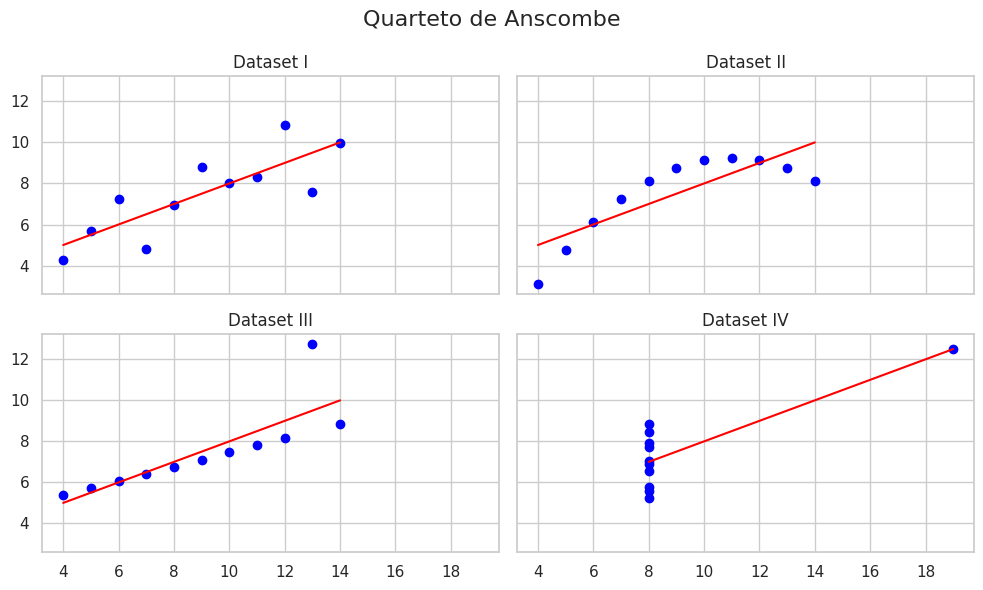

In [4]:
graficos_ascombe()

## Bibliotecas: matplotlib e seaborn

Para criar gráficos em Python, usaremos duas das bibliotecas mais populares:

- **Matplotlib**: É a biblioteca fundamental para visualização em Python. É extremamente poderosa e flexível, permitindo a criação de praticamente qualquer tipo de gráfico. A sua sintaxe pode ser um pouco verbosa, mas seu controle é total.

- **Seaborn**: Construída sobre o Matplotlib, o Seaborn oferece uma interface de mais alto nível para criar gráficos estatísticos atraentes e informativos. Com menos código, conseguimos produzir visualizações mais sofisticadas e esteticamente agradáveis.

### Vamos começar importando as bibliotecas que usaremos hoje.

In [5]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo dos gráficos do seaborn para um visual mais agradável
sns.set_theme(style="whitegrid")

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## Gráficos Básicos: Linhas, Barras e Colunas

Vamos criar um pequeno conjunto de dados para nossos primeiros exemplos.

In [6]:
# Criando um DataFrame de exemplo com dados de vendas mensais de produtos
dados = {
    'mes': ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho'],
    'vendas_produto_A': [150, 200, 180, 220, 250, 210],
    'vendas_produto_B': [80, 95, 90, 110, 130, 120]
}
df_vendas = pd.DataFrame(dados)
print(df_vendas)

         mes  vendas_produto_A  vendas_produto_B
0    Janeiro               150                80
1  Fevereiro               200                95
2      Março               180                90
3      Abril               220               110
4       Maio               250               130
5      Junho               210               120


- **Gráfico de Linhas**: Ideal para visualizar a evolução de uma variável contínua ao longo do tempo.

(para mais parâmetros de customização, visite https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)

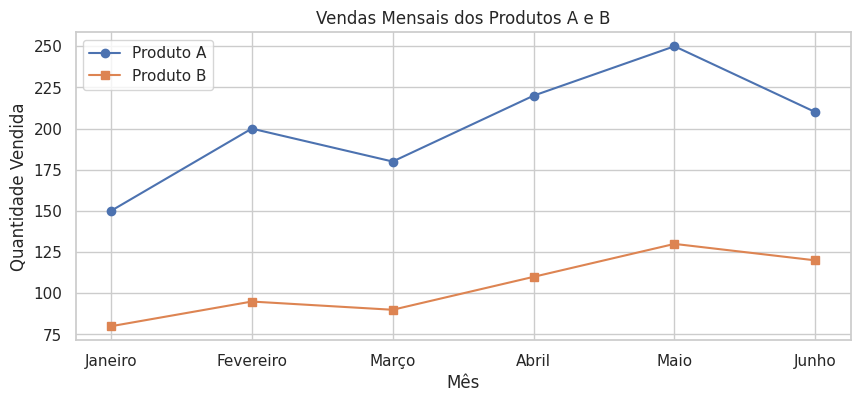

In [7]:
# Gráfico de Linhas com Matplotlib
plt.figure(figsize=(10, 4)) # Define o tamanho da figura
plt.plot(df_vendas['mes'], df_vendas['vendas_produto_A'], marker='o', label='Produto A')
plt.plot(df_vendas['mes'], df_vendas['vendas_produto_B'], marker='s', label='Produto B')

# Adicionando títulos e rótulos
plt.title('Vendas Mensais dos Produtos A e B')
plt.xlabel('Mês')
plt.ylabel('Quantidade Vendida')
plt.legend() # Adiciona a legenda
plt.grid(True) # Adiciona uma grade
plt.show()

- **Gráfico de Barras/Colunas**: Excelente para comparar quantidades entre diferentes categorias.

(para mais informações sobre gráfico de barras do Seaborn, visite https://www.datacamp.com/tutorial/seaborn-barplot ou a doc oficial https://seaborn.pydata.org/generated/seaborn.barplot.html)

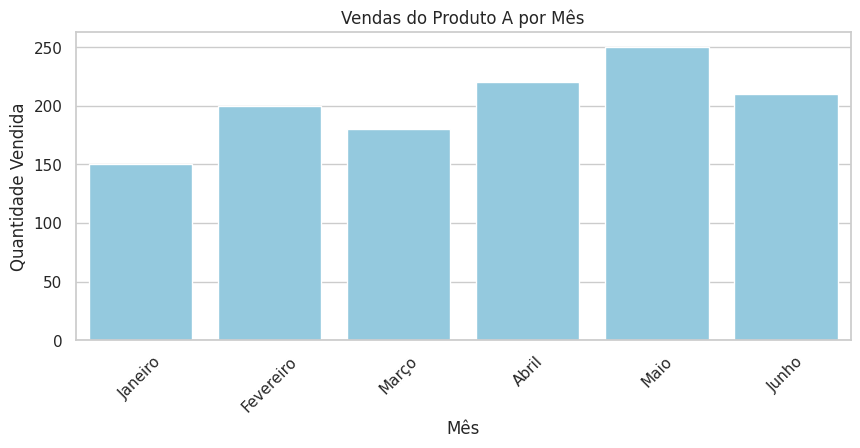

In [8]:
# Gráfico de Barras com Seaborn (mais direto para DataFrames)
plt.figure(figsize=(10, 4))

# Usando o seaborn para criar um gráfico de barras
sns.barplot(x='mes', y='vendas_produto_A', data=df_vendas, color='skyblue')

# Adicionando títulos e rótulos
plt.title('Vendas do Produto A por Mês')
plt.xlabel('Mês')
plt.ylabel('Quantidade Vendida')
plt.xticks(rotation=45) # Rotaciona os rótulos do eixo X para melhor leitura
plt.show()

### Customização e Boas Práticas

Um bom gráfico é, acima de tudo, claro e honesto.

- Títulos e Rótulos: Sempre inclua um título claro e rotule os eixos X e Y, especificando as unidades.
- Cores e Estilos: Use cores de forma consciente. Evite paletas que possam ser confusas para pessoas com daltonismo. O Seaborn possui ótimas paletas de cores prontas.`Para descobrir paletas de cores boas para daltonismo ou xerox, acesse https://colorbrewer2.org/)`
- Simplicidade: Evite elementos desnecessários que possam poluir o gráfico ("chartjunk"). O objetivo é clareza.
- Escala Apropriada: Certifique-se de que a escala dos eixos não distorça a interpretação dos dados.

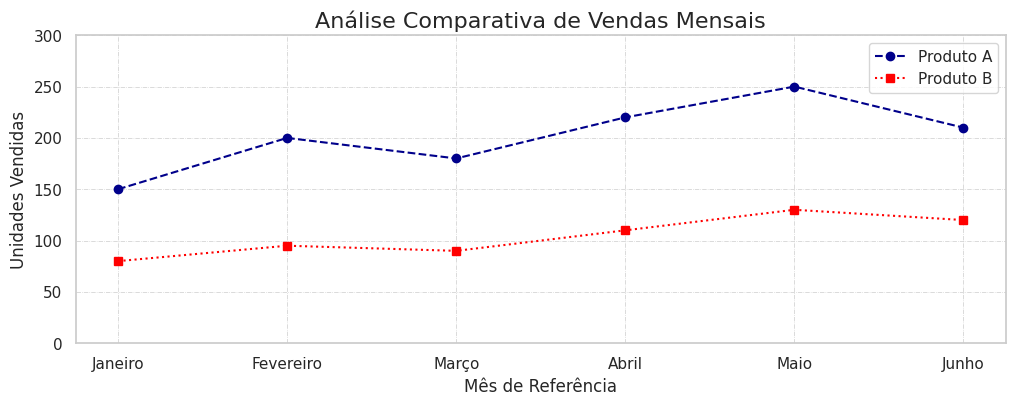

In [9]:
# Customizando o gráfico de linhas anterior
plt.figure(figsize=(12, 4))

plt.plot(df_vendas['mes'], df_vendas['vendas_produto_A'], marker='o', linestyle='--', color='darkblue', label='Produto A')
plt.plot(df_vendas['mes'], df_vendas['vendas_produto_B'], marker='s', linestyle=':', color='red', label='Produto B')

plt.title('Análise Comparativa de Vendas Mensais', fontsize=16)
plt.xlabel('Mês de Referência', fontsize=12)
plt.ylabel('Unidades Vendidas', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='-.', linewidth=0.5)
plt.ylim(0, df_vendas[['vendas_produto_A', 'vendas_produto_B']].max().max() + 50) # Ajustando o limite do eixo Y
plt.show()

## Exercício

Usando o df_vendas, crie um gráfico de barras que compare as vendas totais (Produto A + Produto B) para cada mês.

Dica: Primeiro, crie uma nova coluna 'vendas_totais' no DataFrame.

## Visualizações Avançadas
Agora, vamos explorar gráficos que nos ajudam a entender distribuições e relações entre variáveis. Para isso, vamos carregar um conjunto de dados mais rico. Usaremos o famoso dataset "tips" (gorjetas) que já vem com o Seaborn.

In [10]:
# Carregando o dataset 'tips' do Seaborn
tips = sns.load_dataset("tips")
print("Amostra do dataset 'tips':")
print(tips.head())

Amostra do dataset 'tips':
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


## Histogramas e Gráficos de Distribuição (10 minutos)
Histogramas são essenciais para entender como uma variável numérica se distribui. Eles agrupam os dados em "bins" (caixas) e contam a frequência de observações em cada um.

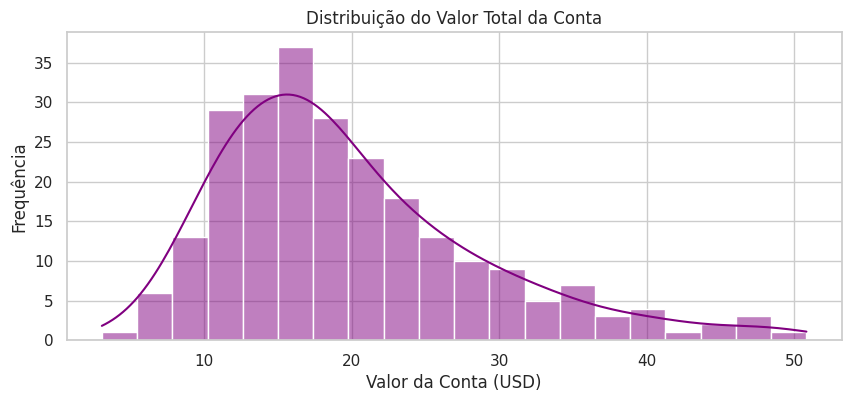

Este gráfico nos mostra que a maioria das contas está concentrada entre 10 e 20 dólares.


In [11]:
# Histograma do valor total da conta
plt.figure(figsize=(10, 4))

sns.histplot(tips['total_bill'], kde=True, bins=20, color='purple')
# O argumento kde=True adiciona uma linha de estimativa de densidade do kernel

plt.title('Distribuição do Valor Total da Conta')
plt.xlabel('Valor da Conta (USD)')
plt.ylabel('Frequência')
plt.show()
print('Este gráfico nos mostra que a maioria das contas está concentrada entre 10 e 20 dólares.')

### Exercício
Crie um histograma para a variável tip (gorjeta) do dataset tips. O que você pode concluir sobre a distribuição das gorjetas?

In [12]:
# TODO - SEU CODE AQUI

## Box Plots para Análise de Outliers

Box plots são fantásticos para resumir a distribuição de uma variável e identificar outliers. Eles exibem o mínimo, o primeiro quartil (Q1), a mediana (Q2), o terceiro quartil (Q3) e o máximo. Os pontos fora dos "bigodes" são geralmente considerados outliers.

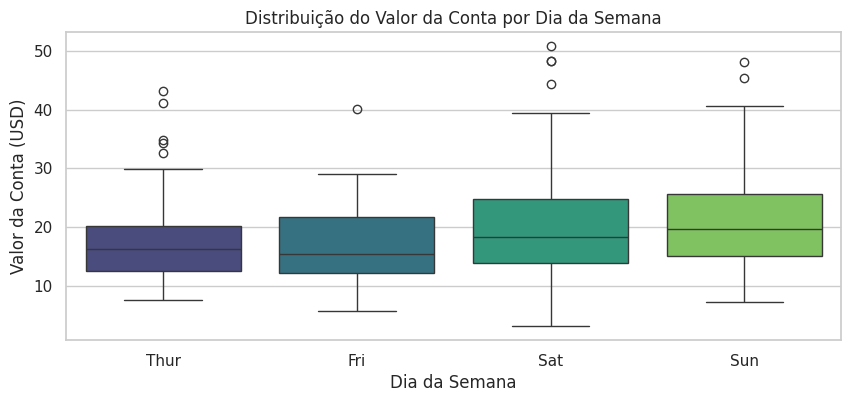

Podemos ver que os valores das contas tendem a ser mais altos nos fins de semana e existem vários outliers (valores muito altos) em todos os dias.


In [13]:
# Box plot do valor total da conta, separado por dia da semana
plt.figure(figsize=(10, 4))

sns.boxplot(x='day', y='total_bill', data=tips, palette='viridis', hue='day', legend=False)

plt.title('Distribuição do Valor da Conta por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Valor da Conta (USD)')
plt.show()
print('Podemos ver que os valores das contas tendem a ser mais altos nos fins de semana e existem vários outliers (valores muito altos) em todos os dias.')

### Exercício
Crie um box plot que compare a distribuição das gorjetas (tip) para fumantes e não fumantes (smoker). Existe alguma diferença notável?

## Gráficos de Setores (Pizza) para Proporções

**Quando usar?** Gráficos de pizza são usados para mostrar a proporção de diferentes categorias que compõem um todo. Pense nele como uma forma de visualizar como 100% de algo é dividido.

`CUIDADO`: Use gráficos de pizza com moderação! Eles se tornam ineficazes e confusos se:
- Você tiver muitas categorias (geralmente mais de 5 ou 6).
- As proporções entre as categorias forem muito semelhantes, pois o olho humano tem dificuldade em comparar o tamanho de ângulos.

Para comparações, um gráfico de barras é quase sempre uma escolha melhor.

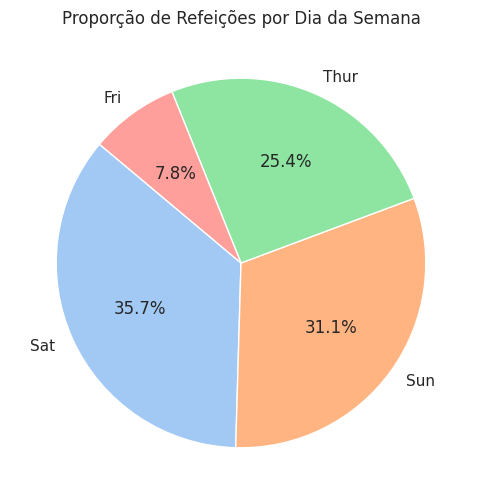

Este gráfico mostra claramente que a maioria das refeições registradas no dataset ocorreu no Sábado e no Domingo.


In [14]:
# Contando a frequência de cada dia
contagem_dias = tips['day'].value_counts()

# Criando o gráfico de pizza
plt.figure(figsize=(8, 6))
plt.pie(contagem_dias, labels=contagem_dias.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
# autopct='%1.1f%%' formata os valores para aparecerem como porcentagens no gráfico
# startangle rotaciona o gráfico para um melhor visual

plt.title('Proporção de Refeições por Dia da Semana')
plt.ylabel('') # Remove o rótulo 'day' que o matplotlib adiciona por padrão
plt.show()
print('Este gráfico mostra claramente que a maioria das refeições registradas no dataset ocorreu no Sábado e no Domingo.')

### **Exercício**

Crie um gráfico de pizza que mostre a proporção de clientes do sexo masculino (`Male`) vs. feminino (`Female`) no dataset `tips`.

In [15]:
# TODO


## Gráficos de Dispersão e Correlação
Gráficos de dispersão (scatter plots) são a melhor forma de visualizar a relação entre duas variáveis numéricas.


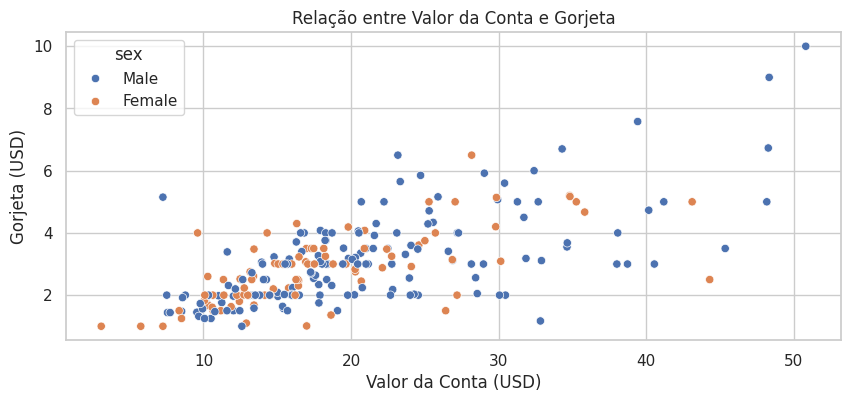

Como esperado, há uma correlação positiva: quanto maior o valor da conta, maior a gorjeta.


In [16]:
# Gráfico de dispersão entre o valor total da conta e a gorjeta
plt.figure(figsize=(10, 4))

# O argumento 'hue' permite colorir os pontos com base em uma terceira variável categórica
sns.scatterplot(x='total_bill', y='tip', hue='sex', data=tips)

plt.title('Relação entre Valor da Conta e Gorjeta')
plt.xlabel('Valor da Conta (USD)')
plt.ylabel('Gorjeta (USD)')
plt.show()
print('Como esperado, há uma correlação positiva: quanto maior o valor da conta, maior a gorjeta.')

## Heatmaps e Pair Plots
Heatmaps (Mapas de Calor): Ótimos para visualizar a matriz de correlação entre múltiplas variáveis numéricas.

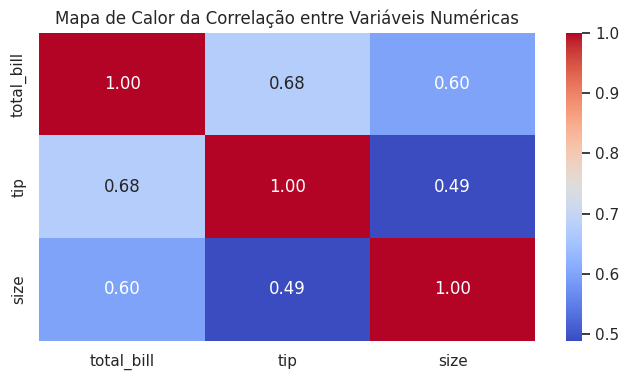

In [17]:
# Selecionando apenas colunas numéricas para a matriz de correlação
numeric_cols = tips.select_dtypes(include=np.number)
correlacao = numeric_cols.corr()
# Criando o heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f")
# annot=True exibe os valores de correlação no mapa
# cmap define a paleta de cores
plt.title('Mapa de Calor da Correlação entre Variáveis Numéricas')
plt.show()

### Pair Plots
Uma do Seaborn que cria uma matriz de gráficos, mostrando a relação par a par entre todas as variáveis de um dataset e a distribuição de cada variável na diagonal.

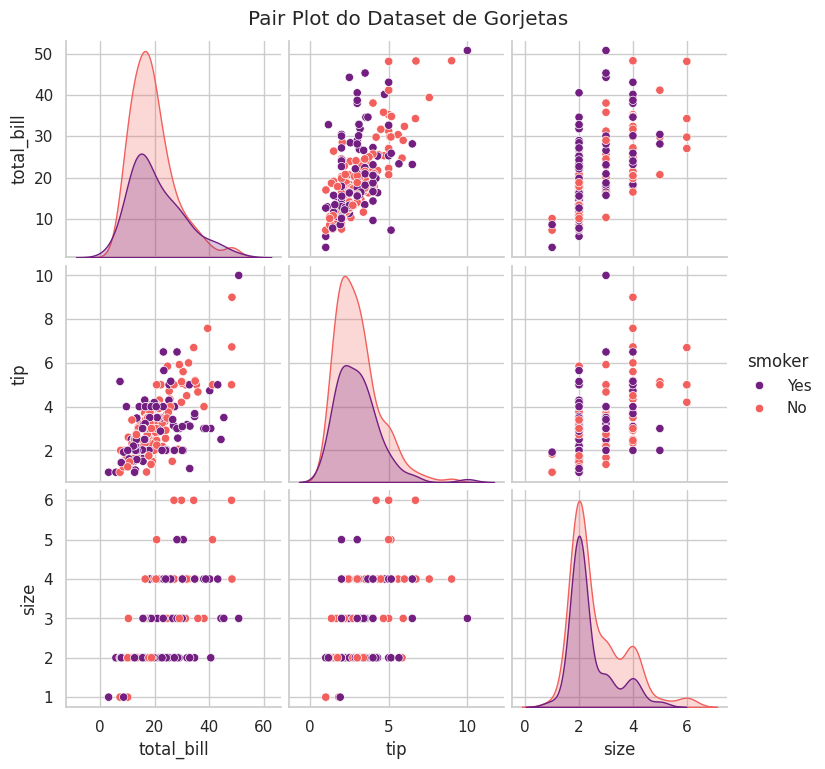

In [18]:
# Criando um pair plot
# Cuidado: pode ser lento para datasets com muitas colunas
sns.pairplot(tips, hue='smoker', palette='magma')
plt.suptitle('Pair Plot do Dataset de Gorjetas', y=1.02) # y ajusta a posição do título
plt.show()

### Exercício
Gere um pairplot para o mesmo dataset tips, mas usando a variável day para colorir os gráficos (argumento hue). O que isso revela?

In [19]:
# TODO - SEU CODE


## Exercício

Nosso objetivo é usar as técnicas de visualização que aprendemos para explorar e entender esses dados.
- Dataset: Global Shark Attacks (`global-shark-attack.csv`)
- **Objetivo**: Realizar uma análise exploratória visual para responder às seguintes perguntas:
    1. Em quais países ocorreram mais ataques?
    2. Como a quantidade de ataques variou ao longo dos anos?
    3. Qual o tipo de ataque mais comum?
    4. Existe alguma relação entre a atividade da vítima e o tipo de ataque?

In [20]:
try:
    df_shark = ...
    df_shark.head()

except:
    print("Arquivo 'global-shark-attack.csv' não encontrado. Por favor, faça o download do Kaggle e coloque na mesma pasta.")

Arquivo 'global-shark-attack.csv' não encontrado. Por favor, faça o download do Kaggle e coloque na mesma pasta.


**Criem as seguintes visualizações com base nas escolhas ideias para cada pergunta:**:
- Países com mais ataques:
- Ataques ao longo do tempo: Gráfico mostrando o número de ataques por ano.
- Tipo de ataque mais comum: Sugerido: Gráfico para a coluna 'AttackType'.
- Atividade da vítima: Gráfico com as 10 atividades mais comuns durante os ataques.


In [21]:
# TODO
